In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


Download the data sets and normalise the data
For MNIST: 
    - Use min-max scaling, so that the values are in range[0,1]
For CIFAR-10:
    -Use Z score normalisation (mean=0, stdev=1)

In [8]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train, y_train), (x_test, y_test) = mnist.load_data()

(x_train_cif, y_train_cif), (x_test_cif, y_test_cif) = cifar10.load_data()

x_train_cif = x_train_cif.astype("float32")
x_test_cif = x_test_cif.astype("float32")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9892114..2.094585].


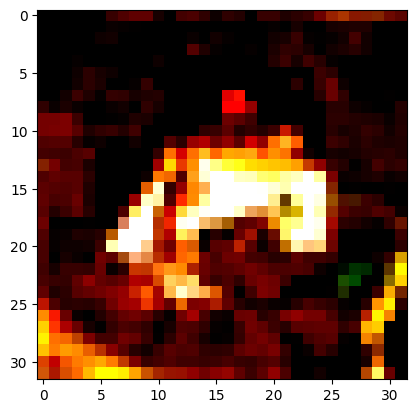

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.909838..2.1008017].


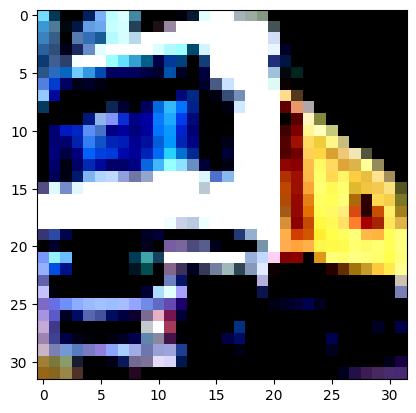

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6581167..2.126797].


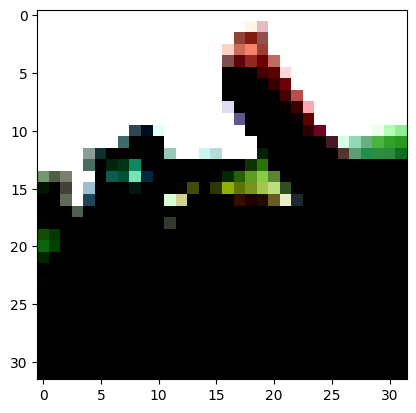

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7708588..1.7254721].


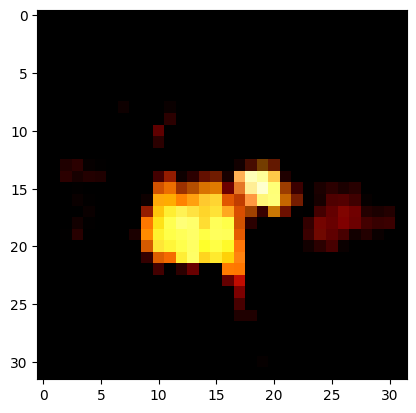

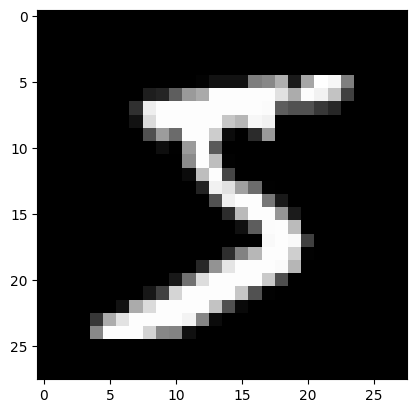

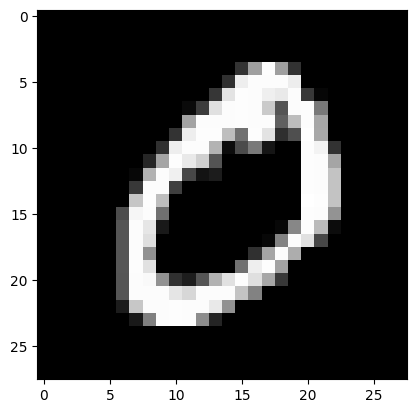

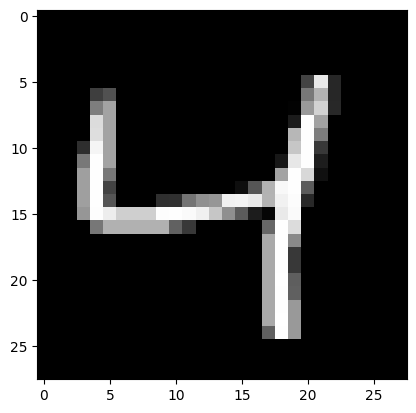

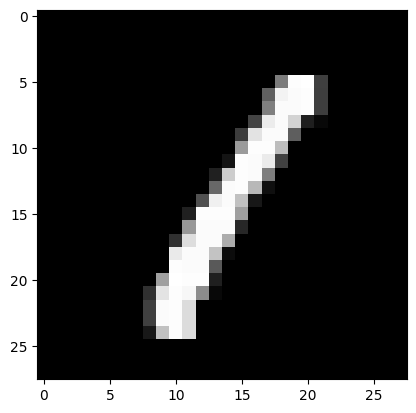

In [9]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure()
for i in range(4):
    plt.imshow(x_train_cif[i])
    plt.show()

    
x_train, x_test = x_train/255.0, x_test/255.0
plt.figure()
for i in range(4):
    plt.imshow(x_train[i], cmap = "gray")
    plt.show()


def z_score_normalisation(train, test):
    mean = np.mean(train, axis= (0,1,2), keepdims=True)
    std = np.std(train, axis= (0,1,2), keepdims=True)

    return (train - mean) / std, (test - mean) / std


x_train_cif, x_test_cif = z_score_normalisation(x_train_cif, x_test_cif)



MNIST. 
Train (with Adam optimizer) a CNN with:
    -First layer: Convolution layer wtih 16-64 filters (3x3), ReLu activation and batch normalisation
    -Second layer: Max pooling (2x2)
    -Third layer: Convolution layer with 32-128 filters (3x3), ReLu activation and batch normalisation
    -Fourth layer: max pooling (2x2)
    -Fifth layer: (after flattening the output from fourth later): A fully connected ("dense") layer with 128 neurons, ReLu activation (and dropout during training with suitable dropout range (somewhere in [0.2, 0.5]))
    -Sixth layer: a layer with 10 neurons (the number of classes) and a softmax activation function

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.BatchNormalization(input_shape=(28, 28, 1)),
    layers.Conv2D(filters=16, kernel_size = (3,3), activation = "relu", input_shape = (28, 28, 1)),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),
    layers.Conv2D(filters=32, kernel_size=(3,3), activation = "relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation = "softmax")
])

model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
fitted = model.fit(x_train, y_train, epochs = 10, batch_size = 64, validation_data = (x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy: ", test_acc)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9408 - loss: 0.1937 - val_accuracy: 0.9825 - val_loss: 0.0598
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9764 - loss: 0.0763 - val_accuracy: 0.9862 - val_loss: 0.0432
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9819 - loss: 0.0590 - val_accuracy: 0.9884 - val_loss: 0.0369
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9855 - loss: 0.0474 - val_accuracy: 0.9847 - val_loss: 0.0488
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9870 - loss: 0.0424 - val_accuracy: 0.9903 - val_loss: 0.0320
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9890 - loss: 0.0359 - val_accuracy: 0.9880 - val_loss: 0.0353
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9897 - loss: 0.0322 - val_accuracy: 0.9907 - val_loss: 0.0291
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9913 - loss: 0.0280 - 